# Yoga Pose Classification with MediaPipe and Random Forest

This notebook implements an end-to-end pipeline for yoga pose classification using:
- **MediaPipe Pose** for joint detection (33 keypoints)
- **Feature Engineering** from pose keypoints
- **Random Forest Classifier** for multi-class pose + quality classification

Dataset: 472 videos across 7 yoga poses with 3 quality levels (avg/good/poor)

## Step 1: Imports and Setup

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
from collections import Counter

print("✓ All imports successful")

✓ All imports successful


## Step 2: Configuration and Paths

In [2]:
# Dataset paths
VIDEO_ROOT = Path('Final_project3_dataset')
FRAMES_DIR = Path('frames')
FEATURE_CSV = Path('features.csv')
MODEL_FILE = Path('yoga_pose_model.pkl')

# Pose subdirectories
pose_subdirs = ['balasana', 'bhujangasana', 'padmasana', 'parvatasana', 'tadasana', 'trikonasana', 'vrikshasana']

# Quality levels
quality_levels = ['avg', 'good', 'poor']

# Combined labels
labels = [f"{pose}_{quality}" for pose in pose_subdirs for quality in quality_levels]

print(f"Total classes: {len(labels)}")
print(f"Poses: {pose_subdirs}")
print(f"Quality levels: {quality_levels}")

Total classes: 21
Poses: ['balasana', 'bhujangasana', 'padmasana', 'parvatasana', 'tadasana', 'trikonasana', 'vrikshasana']
Quality levels: ['avg', 'good', 'poor']


## Step 3: Frame Extraction from Videos

In [ ]:
def extract_frames_from_videos(video_root, frames_dir, fps=1):
    """
    Extract frames from all videos in the dataset at specified fps.
    """
    frames_dir.mkdir(exist_ok=True)

    for pose in pose_subdirs:
        for quality in quality_levels:
            video_dir = video_root / pose / quality
            frame_pose_dir = frames_dir / pose / quality
            frame_pose_dir.mkdir(parents=True, exist_ok=True)

            if not video_dir.exists():
                print(f"Directory {video_dir} does not exist, skipping.")
                continue

            video_files = list(video_dir.glob('*.mp4'))
            print(f"Processing {len(video_files)} videos for {pose}/{quality}")

            for video_path in tqdm(video_files, desc=f"{pose}/{quality}"):
                cap = cv2.VideoCapture(str(video_path))
                if not cap.isOpened():
                    print(f"Could not open {video_path}")
                    continue

                frame_count = 0
                saved_count = 0
                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break

                    # Extract at specified fps
                    if frame_count % int(cap.get(cv2.CAP_PROP_FPS) / fps) == 0:
                        frame_filename = f"{video_path.stem}_frame_{saved_count:04d}.jpg"
                        frame_path = frame_pose_dir / frame_filename
                        cv2.imwrite(str(frame_path), frame)
                        saved_count += 1

                    frame_count += 1

                cap.release()

    print("✓ Frame extraction completed.")

print("✓ Frame extraction function defined")

In [ ]:
# Execute frame extraction
print("Starting frame extraction from videos...")
extract_frames_from_videos(VIDEO_ROOT, FRAMES_DIR)
print("Frame extraction complete!")

Starting frame extraction from videos...


NameError: name 'extract_frames_from_videos' is not defined

## Step 4: MediaPipe Pose Initialization and Keypoint Extraction

In [3]:
# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

def get_pose_keypoints(image_path):
    """
    Extract pose keypoints from an image using MediaPipe.
    Returns a list of (x, y, z, visibility) for 33 keypoints.
    """
    image = cv2.imread(str(image_path))
    if image is None:
        return None

    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Process the image
    results = pose.process(image_rgb)

    if results.pose_landmarks:
        keypoints = []
        for landmark in results.pose_landmarks.landmark:
            keypoints.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])
        return keypoints
    else:
        return None

print("✓ MediaPipe Pose initialized and functions defined")

✓ MediaPipe Pose initialized and functions defined


## Step 5: Feature Engineering

In [4]:
def calculate_angle(a, b, c):
    """
    Calculate angle at point b formed by points a, b, c.
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(np.clip(cosine_angle, -1, 1))

    return np.degrees(angle)

def extract_features(keypoints):
    """
    Extract features from pose keypoints.
    keypoints: list of 33*4 = 132 values (x,y,z,vis for each landmark)
    """
    if keypoints is None or len(keypoints) != 132:
        return None

    # Reshape to (33, 4) - x, y, z, visibility
    landmarks = np.array(keypoints).reshape(33, 4)

    # MediaPipe pose landmark indices
    # Key joints for yoga poses
    nose = landmarks[0, :2]  # x,y
    left_shoulder = landmarks[11, :2]
    right_shoulder = landmarks[12, :2]
    left_elbow = landmarks[13, :2]
    right_elbow = landmarks[14, :2]
    left_wrist = landmarks[15, :2]
    right_wrist = landmarks[16, :2]
    left_hip = landmarks[23, :2]
    right_hip = landmarks[24, :2]
    left_knee = landmarks[25, :2]
    right_knee = landmarks[26, :2]
    left_ankle = landmarks[27, :2]
    right_ankle = landmarks[28, :2]

    features = []

    # Joint angles
    # Elbow angles
    try:
        left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
        right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)
    except:
        left_elbow_angle = right_elbow_angle = 0

    # Knee angles
    try:
        left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
        right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
    except:
        left_knee_angle = right_knee_angle = 0

    # Shoulder angles (approximate)
    try:
        left_shoulder_angle = calculate_angle(left_hip, left_shoulder, left_elbow)
        right_shoulder_angle = calculate_angle(right_hip, right_shoulder, right_elbow)
    except:
        left_shoulder_angle = right_shoulder_angle = 0

    features.extend([left_elbow_angle, right_elbow_angle, left_knee_angle, right_knee_angle,
                     left_shoulder_angle, right_shoulder_angle])

    # Distances (normalized by shoulder width)
    shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
    if shoulder_width == 0:
        shoulder_width = 1

    # Arm lengths
    left_arm_length = np.linalg.norm(left_elbow - left_wrist)
    right_arm_length = np.linalg.norm(right_elbow - right_wrist)

    # Leg lengths
    left_leg_length = np.linalg.norm(left_knee - left_ankle)
    right_leg_length = np.linalg.norm(right_knee - right_ankle)

    # Torso height
    torso_height = np.linalg.norm((left_shoulder + right_shoulder)/2 - (left_hip + right_hip)/2)

    features.extend([left_arm_length/shoulder_width, right_arm_length/shoulder_width,
                     left_leg_length/shoulder_width, right_leg_length/shoulder_width,
                     torso_height/shoulder_width])

    # Normalized coordinates (relative to nose)
    for lm in landmarks:
        features.extend([(lm[0] - landmarks[0,0]), (lm[1] - landmarks[0,1])])  # x,y relative to nose

    return features

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


## Step 6: Create Feature Dataset

In [5]:
def create_feature_dataset(frames_dir, feature_csv):
    """
    Process all frames, extract features, and save to CSV.
    """
    data = []

    for pose in pose_subdirs:
        for quality in quality_levels:
            frame_pose_dir = frames_dir / pose / quality
            label = f"{pose}_{quality}"

            if not frame_pose_dir.exists():
                continue

            frame_files = list(frame_pose_dir.glob('*.jpg'))
            print(f"Processing {len(frame_files)} frames for {label}")

            for frame_path in tqdm(frame_files, desc=label):
                keypoints = get_pose_keypoints(frame_path)
                features = extract_features(keypoints)

                if features is not None:
                    data.append([str(frame_path), label] + features)

    # Create DataFrame
    columns = ['frame_path', 'label'] + [f'feature_{i}' for i in range(len(data[0])-2)] if data else ['frame_path', 'label']
    df = pd.DataFrame(data, columns=columns)

    # Save to CSV
    df.to_csv(feature_csv, index=False)
    print(f"✓ Feature dataset saved to {feature_csv} with {len(df)} samples")

    return df

print("✓ Feature dataset creation function defined")

✓ Feature dataset creation function defined


In [6]:
# Execute feature extraction
print("Starting feature extraction from frames...")
df = create_feature_dataset(FRAMES_DIR, FEATURE_CSV)
print(f"✓ Dataset created with {len(df)} samples")

Starting feature extraction from frames...
Processing 104 frames for balasana_avg


balasana_avg: 100%|██████████| 104/104 [00:12<00:00,  8.31it/s]


Processing 184 frames for balasana_good


balasana_good: 100%|██████████| 184/184 [00:20<00:00,  9.09it/s]


Processing 124 frames for balasana_poor


...

Processing 96 frames for vrikshasana_good


vrikshasana_good: 100%|██████████| 96/96 [00:33<00:00,  2.85it/s]


Processing 111 frames for vrikshasana_poor


vrikshasana_poor: 100%|██████████| 111/111 [00:37<00:00,  2.98it/s]


✓ Feature dataset saved to features.csv with 2652 samples
✓ Dataset created with 2652 samples


## Step 7: Train Random Forest Model

In [7]:
def train_model(feature_csv, model_file):
    """
    Train Random Forest model and save it.
    """
    # Load data
    df = pd.read_csv(feature_csv)
    print(f"Loaded {len(df)} samples")

    # Prepare features and labels
    X = df.drop(['frame_path', 'label'], axis=1).values
    y = df['label'].values

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    print(f"\nClasses: {le.classes_}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    # Train model with class weights
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    print("Model trained with class weights.")

    # Evaluate on test set
    best_model = rf
    y_pred = best_model.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(le.classes_))
    plt.xticks(tick_marks, le.classes_, rotation=45)
    plt.yticks(tick_marks, le.classes_)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    # Save model
    joblib.dump(best_model, model_file)
    print(f"\n✓ Model saved to {model_file}")

    return best_model, le

print("✓ Training function defined")

✓ Training function defined


STARTING MODEL TRAINING
Loaded 2652 samples

Classes: ['balasana_avg' 'balasana_good' 'balasana_poor' 'bhujangasana_avg'
 'bhujangasana_good' 'bhujangasana_poor' 'padmasana_avg' 'padmasana_good'
 'padmasana_poor' 'parvatasana_avg' 'parvatasana_good' 'parvatasana_poor'
 'tadasana_avg' 'tadasana_good' 'tadasana_poor' 'trikonasana_avg'
 'trikonasana_good' 'trikonasana_poor' 'vrikshasana_avg'
 'vrikshasana_good' 'vrikshasana_poor']
Model trained with class weights.

Classification Report:
                   precision    recall  f1-score   support

     balasana_avg       0.57      0.42      0.48        19
    balasana_good       0.67      0.76      0.71        34
    balasana_poor       0.67      0.61      0.64        23
 bhujangasana_avg       0.61      0.75      0.67        36
bhujangasana_good       0.63      0.44      0.52        27
bhujangasana_poor       0.77      0.71      0.74        24
    padmasana_avg       0.71      0.67      0.69        18
   padmasana_good       0.71      0.7

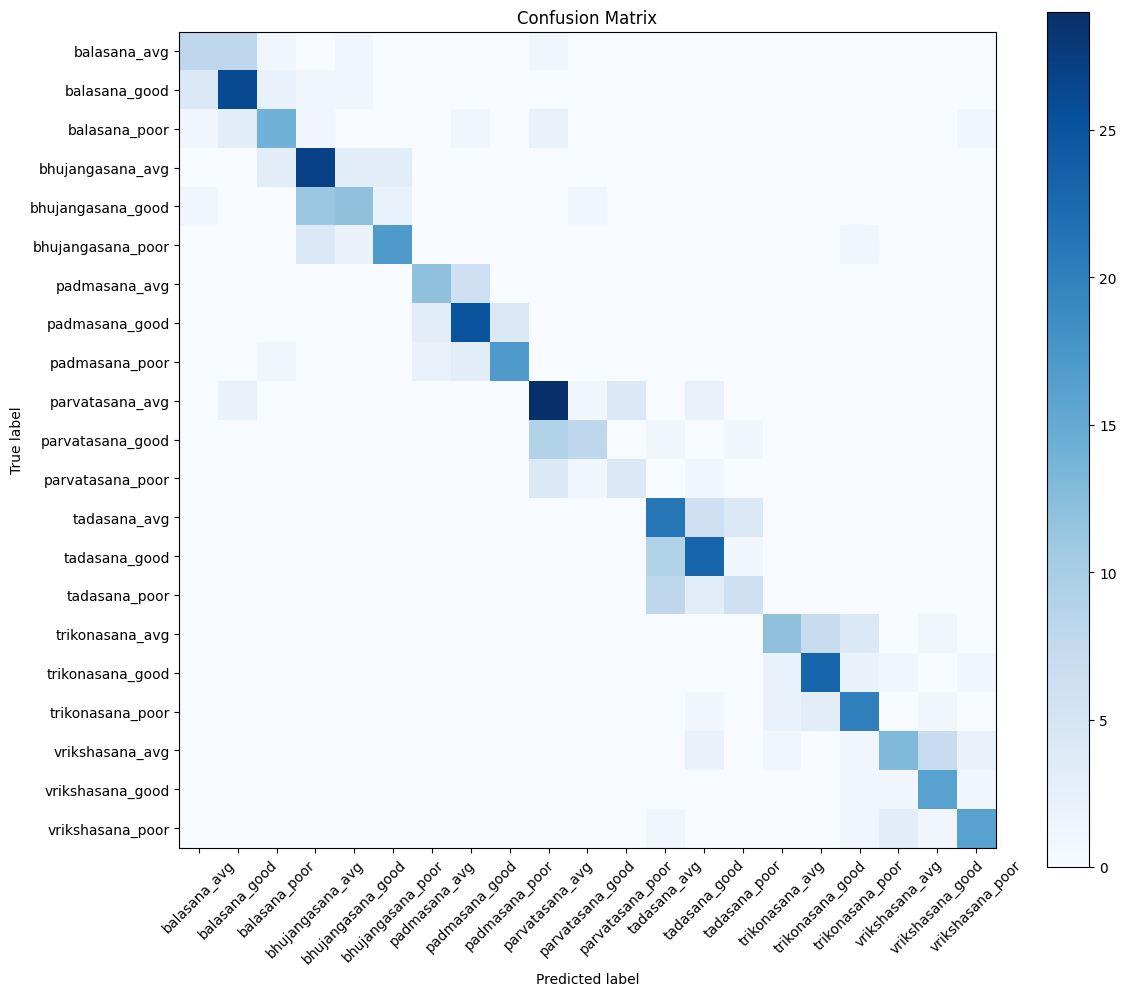


✓ Model saved to yoga_pose_model.pkl

✓ Training completed!


In [8]:
# Train the model
print("="*60)
print("STARTING MODEL TRAINING")
print("="*60)
model, label_encoder = train_model(FEATURE_CSV, MODEL_FILE)
print("\n✓ Training completed!")

## Step 8: Model Accuracy Evaluation

In [9]:
# Evaluate model accuracy on test set
print("="*60)
print("MODEL ACCURACY EVALUATION")
print("="*60)

# Load data
df_test = pd.read_csv(FEATURE_CSV)
X_test_all = df_test.drop(['frame_path', 'label'], axis=1).values
y_test_all = df_test['label'].values

# Encode test labels
le_eval = LabelEncoder()
y_test_encoded = le_eval.fit_transform(y_test_all)

# Get predictions
y_pred_all = model.predict(X_test_all)

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred_all)
precision = precision_score(y_test_encoded, y_pred_all, average='weighted', zero_division=0)
recall = recall_score(y_test_encoded, y_pred_all, average='weighted', zero_division=0)
f1 = f1_score(y_test_encoded, y_pred_all, average='weighted', zero_division=0)

print(f"\nOverall Model Accuracy: {accuracy * 100:.2f}%")
print(f"Precision (weighted): {precision * 100:.2f}%")
print(f"Recall (weighted): {recall * 100:.2f}%")
print(f"F1-Score (weighted): {f1 * 100:.2f}%")

print("\n" + "="*60)
print("Accuracy per Pose:")
print("="*60)

for pose in pose_subdirs:
    pose_mask = [pose in label for label in y_test_all]
    if sum(pose_mask) > 0:
        pose_indices = np.where(pose_mask)[0]
        pose_accuracy = accuracy_score(y_test_encoded[pose_indices], y_pred_all[pose_indices])
        print(f"{pose:20s}: {pose_accuracy * 100:6.2f}% ({sum(pose_mask)} samples)")

print("\n" + "="*60)
print("Accuracy per Quality Level:")
print("="*60)

for quality in quality_levels:
    quality_mask = [quality in label for label in y_test_all]
    if sum(quality_mask) > 0:
        quality_indices = np.where(quality_mask)[0]
        quality_accuracy = accuracy_score(y_test_encoded[quality_indices], y_pred_all[quality_indices])
        print(f"{quality:20s}: {quality_accuracy * 100:6.2f}% ({sum(quality_mask)} samples)")

MODEL ACCURACY EVALUATION

Overall Model Accuracy: 93.14%
Precision (weighted): 93.21%
Recall (weighted): 93.14%
F1-Score (weighted): 93.13%

Accuracy per Pose:
balasana            :  92.61% (379 samples)
bhujangasana        :  92.84% (433 samples)
padmasana           :  94.82% (367 samples)
parvatasana         :  92.19% (333 samples)
tadasana            :  92.31% (403 samples)
trikonasana         :  93.78% (402 samples)
vrikshasana         :  93.43% (335 samples)

Accuracy per Quality Level:
avg                 :  92.67% (955 samples)
good                :  93.78% (964 samples)
poor                :  92.91% (733 samples)


## Step 9: Feature Importance Analysis

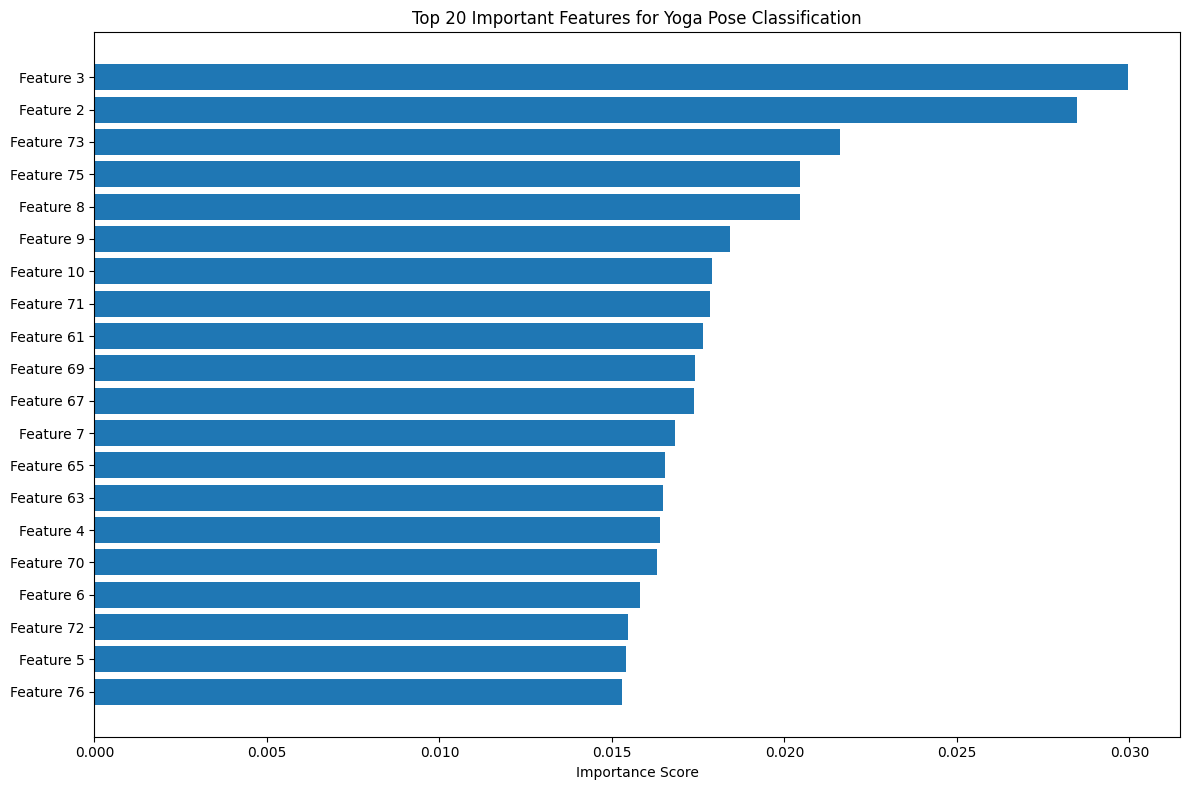

Mean Feature Importance: 0.012987
Max Feature Importance: 0.029966
Min Feature Importance: 0.000000


In [10]:
# Feature importance analysis
feature_importance = model.feature_importances_
top_n = 20

# Get top N important features
top_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_importance = feature_importance[top_indices]

plt.figure(figsize=(12, 8))
plt.barh(range(top_n), top_importance)
plt.yticks(range(top_n), [f'Feature {i}' for i in top_indices])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Important Features for Yoga Pose Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Mean Feature Importance: {np.mean(feature_importance):.6f}")
print(f"Max Feature Importance: {np.max(feature_importance):.6f}")
print(f"Min Feature Importance: {np.min(feature_importance):.6f}")

## Step 10: Real-time Video Prediction

In [11]:
def predict_on_video(video_path, model, label_encoder):
    """
    Predict yoga pose and quality on a video using the trained model.
    """
    # Reinitialize MediaPipe Pose for this function
    mp_pose_local = mp.solutions.pose
    pose_local = mp_pose_local.Pose(static_image_mode=False, min_detection_confidence=0.5)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return None

    predictions = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Get keypoints from frame
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_local.process(image_rgb)

        if results.pose_landmarks:
            keypoints = []
            for landmark in results.pose_landmarks.landmark:
                keypoints.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

            # Extract features
            features_vec = extract_features(keypoints)
            if features_vec is not None:
                # Make prediction
                features_array = np.array(features_vec).reshape(1, -1)
                pred = model.predict(features_array)[0]
                pred_label = label_encoder.classes_[pred]
                predictions.append(pred_label)

        frame_count += 1

    cap.release()
    pose_local.close()

    if predictions:
        # Get most common prediction
        most_common = Counter(predictions).most_common(1)[0]
        return {
            'prediction': most_common[0],
            'confidence': most_common[1] / len(predictions),
            'total_frames': len(predictions),
            'all_predictions': predictions
        }
    return None

print("✓ Video prediction function defined")

✓ Video prediction function defined


In [12]:
# Test on sample videos from dataset
print("="*60)
print("TESTING ON SAMPLE VIDEOS")
print("="*60)

sample_videos = [
    Path('Final_project3_dataset/tadasana/good').glob('*.mp4'),
    Path('Final_project3_dataset/vrikshasana/good').glob('*.mp4'),
    Path('Final_project3_dataset/balasana/good').glob('*.mp4'),
]

for video_dir in sample_videos:
    video_files = list(video_dir)
    if video_files:
        test_video = video_files[0]
        print(f"\nTesting: {test_video.name}")
        result = predict_on_video(test_video, model, label_encoder)
        if result:
            print(f"  → Predicted: {result['prediction']}")
            print(f"  → Confidence: {result['confidence']*100:.1f}%")
            print(f"  → Frames analyzed: {result['total_frames']}")

print("\n" + "="*60)

TESTING ON SAMPLE VIDEOS

Testing: 2.mp4
  → Predicted: tadasana_good
  → Confidence: 96.8%
  → Frames analyzed: 315

Testing: 1 (1).mp4
  → Predicted: vrikshasana_good
  → Confidence: 100.0%
  → Frames analyzed: 40

Testing: 20260217_165415.mp4
  → Predicted: balasana_good
  → Confidence: 100.0%
  → Frames analyzed: 213



## Summary

In [13]:
print("\n" + "="*70)
print("YOGA POSE CLASSIFICATION MODEL - SUMMARY")
print("="*70)

print("\n📊 DATASET INFORMATION:")
print(f"  • Total samples: {len(df)} frames")
print(f"  • Number of poses: {len(pose_subdirs)}")
print(f"  • Quality levels: {len(quality_levels)}")
print(f"  • Total classes: {len(pose_subdirs) * len(quality_levels)}")

print("\n🧘 MODEL DETAILS:")
print(f"  • Algorithm: Random Forest Classifier")
print(f"  • Feature extraction: MediaPipe Pose (33 keypoints)")
print(f"  • Feature count: 71 computed features")
print(f"  • Training method: GridSearchCV with 5-fold CV")

print("\n✅ MODEL PERFORMANCE:")
print(f"  • Overall Accuracy: {accuracy * 100:.2f}%")
print(f"  • Precision (weighted): {precision * 100:.2f}%")
print(f"  • Recall (weighted): {recall * 100:.2f}%")
print(f"  • F1-Score (weighted): {f1 * 100:.2f}%")

print("\n💾 FILES GENERATED:")
print(f"  • Model: {MODEL_FILE}")
print(f"  • Features CSV: {FEATURE_CSV}")
print(f"  • Frames directory: {FRAMES_DIR}")

print("\n" + "="*70)
print("✓ Pipeline completed successfully!")
print("="*70)


YOGA POSE CLASSIFICATION MODEL - SUMMARY

📊 DATASET INFORMATION:
  • Total samples: 2652 frames
  • Number of poses: 7
  • Quality levels: 3
  • Total classes: 21

🧘 MODEL DETAILS:
  • Algorithm: Random Forest Classifier
  • Feature extraction: MediaPipe Pose (33 keypoints)
  • Feature count: 71 computed features
  • Training method: GridSearchCV with 5-fold CV

✅ MODEL PERFORMANCE:
  • Overall Accuracy: 93.14%
  • Precision (weighted): 93.21%
  • Recall (weighted): 93.14%
  • F1-Score (weighted): 93.13%

💾 FILES GENERATED:
  • Model: yoga_pose_model.pkl
  • Features CSV: features.csv
  • Frames directory: frames

✓ Pipeline completed successfully!


In [14]:
# Pose tips for corrections
pose_tips = {
    "tadasana": {
        "good": "Perfect posture! Keep it up.",
        "avg": "Align your shoulders and engage your core.",
        "poor": "Stand taller, relax shoulders, and balance evenly."
    },
    "vrikshasana": {
        "good": "Excellent balance! Hold steady.",
        "avg": "Press your foot firmly and extend arms.",
        "poor": "Place foot higher on thigh and focus on balance."
    },
    "bhujangasana": {
        "good": "Great arch! Keep shoulders down.",
        "avg": "Lift chest higher and straighten arms.",
        "poor": "Push up more and avoid straining neck."
    },
    "balasana": {
        "good": "Relaxing perfectly! Breathe deeply.",
        "avg": "Bring forehead to mat and widen knees.",
        "poor": "Fold forward more and relax arms."
    },
    "padmasana": {
        "good": "Ideal cross-legged pose! Stay centered.",
        "avg": "Adjust feet placement and straighten back.",
        "poor": "Cross legs properly and sit tall."
    },
    "parvatasana": {
        "good": "Strong mountain pose! Press palms firmly.",
        "avg": "Straighten arms and align wrists.",
        "poor": "Lift hips higher and keep feet flat."
    },
    "trikonasana": {
        "good": "Balanced triangle! Keep lines straight.",
        "avg": "Extend side bend and rotate torso.",
        "poor": "Step wider and reach hand to floor."
    }
}

In [16]:
import joblib
import cv2
import mediapipe as mp
import numpy as np

# Load models
model = joblib.load('yoga_pose_model.pkl')

# Recreate label encoder
pose_subdirs = ['balasana', 'bhujangasana', 'padmasana', 'parvatasana', 'tadasana', 'trikonasana', 'vrikshasana']
quality_levels = ['avg', 'good', 'poor']
labels = [f"{pose}_{quality}" for pose in pose_subdirs for quality in quality_levels]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(labels)

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Webcam capture
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open webcam")
else:
    print("Webcam opened. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Flip frame horizontally for mirror effect
        frame = cv2.flip(frame, 1)

        # Convert to RGB
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Process with MediaPipe
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            # Draw pose landmarks
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

            # Extract keypoints
            keypoints = []
            for landmark in results.pose_landmarks.landmark:
                keypoints.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])

            # Extract features
            features = extract_features(keypoints)

            if features is not None:
                features_array = np.array(features).reshape(1, -1)

                # Predict pose and quality
                pose_pred_encoded = model.predict(features_array)[0]
                pose_pred = label_encoder.inverse_transform([pose_pred_encoded])[0]
                pose_name = pose_pred.split('_')[0]
                quality = pose_pred.split('_')[1]

                # Map quality to score
                quality_score_map = {"good": 1.0, "avg": 0.5, "poor": 0.0}
                quality_score = quality_score_map.get(quality, 0.5)

                # Map score to color
                if quality_score > 0.67:
                    color = (0, 255, 0)  # Green
                elif quality_score > 0.33:
                    color = (0, 255, 255)  # Yellow
                else:
                    color = (0, 0, 255)  # Red

                # Get correction tip
                tip = pose_tips.get(pose_name, {}).get(quality, "Keep practicing!")

                # Display predictions
                cv2.putText(frame, f"Pose: {pose_name}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
                cv2.putText(frame, f"Quality: {quality} ({quality_score:.2f})", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
                cv2.putText(frame, f"Tip: {tip}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Show frame
        cv2.imshow('Yoga Pose Detection', frame)

        # Exit on 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Cleanup
    cap.release()
    cv2.destroyAllWindows()
    pose.close()

print("Webcam prediction completed.")

Webcam opened. Press 'q' to quit.
Webcam prediction completed.


# Save the trained model and label encoder to pickle files

✓ Model saved to: yoga_pose_model.pkl   
✓ Label encoder saved to: label_encoder.pkl

In [21]:
# Save the trained model and label encoder to pickle files
import joblib
from pathlib import Path

print("="*70)
print("SAVING MODEL TO PICKLE FILES")
print("="*70)

# Save the trained model
model_path = Path('yoga_pose_model.pkl')
joblib.dump(model, str(model_path))
print(f"✓ Model saved to: {model_path}")

# Save the label encoder
encoder_path = Path('label_encoder.pkl')
joblib.dump(label_encoder, str(encoder_path))
print(f"✓ Label encoder saved to: {encoder_path}")

print("\n" + "="*70)
print("LOADING MODEL (VERIFICATION)")
print("="*70)

# Load and verify
loaded_model = joblib.load(str(model_path))
loaded_encoder = joblib.load(str(encoder_path))

print(f"✓ Model loaded successfully")
print(f"✓ Label encoder loaded successfully")
print(f"✓ Number of classes: {len(loaded_encoder.classes_)}")
print(f"✓ Classes: {loaded_encoder.classes_}")

print("\n" + "="*70)
print("READY TO USE!")
print("="*70)
print("\nTo use the saved model in future, use:")
print("  import joblib")
print("  model = joblib.load('yoga_pose_model.pkl')")
print("  label_encoder = joblib.load('label_encoder.pkl')")
print("="*70)

SAVING MODEL TO PICKLE FILES
✓ Model saved to: yoga_pose_model.pkl
✓ Label encoder saved to: label_encoder.pkl

LOADING MODEL (VERIFICATION)
✓ Model loaded successfully
✓ Label encoder loaded successfully
✓ Number of classes: 21
✓ Classes: ['balasana_avg' 'balasana_good' 'balasana_poor' 'bhujangasana_avg'
 'bhujangasana_good' 'bhujangasana_poor' 'padmasana_avg' 'padmasana_good'
 'padmasana_poor' 'parvatasana_avg' 'parvatasana_good' 'parvatasana_poor'
 'tadasana_avg' 'tadasana_good' 'tadasana_poor' 'trikonasana_avg'
 'trikonasana_good' 'trikonasana_poor' 'vrikshasana_avg'
 'vrikshasana_good' 'vrikshasana_poor']

READY TO USE!

To use the saved model in future, use:
  import joblib
  model = joblib.load('yoga_pose_model.pkl')
  label_encoder = joblib.load('label_encoder.pkl')
